# 3단계 — 파이프라인 추론 (탐지 + 분류 연결)

## 이 노트북의 역할
학습이 끝난 두 모델을 연결해 "위치 + 차종"을 한 번에 출력하는 최종 단계:
```
DOM 장면 → SAHI+YOLO(위치 탐지) → 박스 중심 128×128 창 크롭 → 분류기(차종 판별) → 박스+차종+신뢰도
```

## 두 가지 평가를 수행
1. **슬라이스 정량 평가** (파트 A): SOC-50 test 슬라이스 전체에서 "탐지 성공 + 차종 정답" 비율 측정.
   분류기 단독 정확도와의 차이 = **탐지 단계 손실** (보고서 핵심 수치)
2. **DOM 장면 멀티 객체 시연** (파트 B): 실제 장면(~3000px)에서 차량 수십 대를 동시에 탐지+판별.
   장면 어노테이션으로 정량 평가까지 (보고서 핵심 그림)

## stage1 확정 사항 반영 (중요)
stage1 실험에서 확정한 설정을 그대로 사용한다:
- **tif 1채널 문제**: ultralytics(cv2)는 tif를 1채널로 읽어 에러 → 모든 탐지 입력은
  `PIL .convert("RGB")`로 3채널 변환 후 numpy 배열로 전달
- **SAHI 설정**: 타일 256×256 / overlap 0.25 / `perform_standard_pred=False`(거대 박스 방지)
- **conf=0.5**: conf 스윕 실험 결과 (0.5까지 장면 recall 38/40 유지, 0.6부터 하락)
- **크기 필터**: 폭/높이 100px 이상 박스 제거 (차량 최대 ~60px)

## 사전 준비 (드라이브 MyDrive/ATRNet-STAR/)
- `checkpoints/yolo_detector.pt` ← stage1 결과
- `checkpoints/resnet18_soc50_final.pth` ← stage2 결과 (다른 분류기로 교체 가능)
- `soc50.tar` (파트 A용), `dom_scenes.tar` (파트 B용)
- 런타임 → T4 GPU

## 1. 환경 준비

ultralytics(YOLO) + sahi(타일링 추론) 설치, 드라이브 마운트.

In [ ]:
import torch
from google.colab import drive
drive.mount('/content/drive')

!pip -q install ultralytics sahi

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.7 MB/s eta 0:00:00
device: cuda


## 2. 데이터 준비 (슬라이스 + DOM 장면)

드라이브 tar 두 개를 코랩 로컬에 해제 (이미 있으면 건너뜀):
- `soc50.tar` → 파트 A의 평가 입력 (test 슬라이스)
- `dom_scenes.tar` → 파트 B의 추론 입력 (전체 장면 + 정답 xml)

In [ ]:
import os, glob

# ----- SOC-50 슬라이스 -----
SETTING  = "SOC_50classes"
DATA_DIR = f"/content/{SETTING}"
if not os.path.exists(DATA_DIR):
    !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar

TEST_DIR = os.path.join(DATA_DIR, "test")    # ▼ 실제 폴더명 확인 후 수정

# ----- DOM 장면 -----
if not os.path.exists("/content/raw_scenes"):
    !cp "{SAVE_DIR}/dom_scenes.tar" /content/dom_scenes.tar
    !tar -xf /content/dom_scenes.tar -C /content/ && rm /content/dom_scenes.tar

scene_tifs = sorted(glob.glob("/content/raw_scenes/**/DOM*.tif", recursive=True))
print(f"test 슬라이스 클래스 수: {len(os.listdir(TEST_DIR))} / DOM 장면: {len(scene_tifs)}장")

test 슬라이스 클래스 수: 50 / DOM 장면: 48장


## 3. 두 모델 로드

- **탐지기**: stage1의 best 가중치를 SAHI 래퍼로 로드 (conf=0.5, image_size=256 — stage1 확정값)
- **분류기**: stage2의 final 가중치. **다른 분류기로 바꾸려면 아래 "분류기 블록"만 교체**
  (가중치를 읽으려면 같은 구조의 모델을 먼저 만들어야 하므로 모델 정의 + 경로 둘 다 수정)
- **클래스 순서**: 학습 때 ImageFolder가 쓴 폴더명 알파벳순과 동일해야 라벨이 맞음 →
  test 폴더에서 다시 읽어 일치 보장

In [ ]:
import torch.nn as nn
from torchvision.models import convnext_tiny
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# ===== 1단계: 탐지기 (stage1 확정 설정) =====
DET_CONF = 0.5                     # conf 스윕 결과: 0.5까지 recall 38/40 유지
det_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=f"{SAVE_DIR}/checkpoints/yolo_detector.pt",
    confidence_threshold=DET_CONF,
    device="cuda:0",
    image_size=256,                # 타일을 256으로 추론 (축소 최소화 — stage1 확정)
)

# ===== 2단계: 분류기 (모델 교체 시 이 블록만 수정) =====
CLASS_NAMES = sorted(os.listdir(TEST_DIR))    # ImageFolder와 같은 알파벳순 — 순서 불일치 시 라벨 엉킴
NUM_CLASSES = len(CLASS_NAMES)

classifier = convnext_tiny()
classifier.classifier[2] = nn.Linear(classifier.classifier[2].in_features, NUM_CLASSES)
classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/convnext_soc50_final.pth", map_location=device))
classifier = classifier.to(device).eval()

print(f"탐지기(conf={DET_CONF}) + 분류기({NUM_CLASSES}클래스) 로드 완료")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
탐지기(conf=0.5) + 분류기(50클래스) 로드 완료


## 4. 공통 함수 — 크롭 + 분류

### 핵심: 고정 128×128 창 크롭 (스케일 일치)
분류기가 학습한 SOC-50 슬라이스는 "128×128 안에 차량이 ~40px + 넓은 배경" 구조다.
처음 버전은 박스를 딱 맞게(+20% 마진) 잘라 128로 확대했는데, 그러면 차량이 화면의
80%를 차지하는 — 학습 때 본 적 없는 — 분포가 되어 분류가 완전히 무너졌다
(실험 결과: 장면 분류 정확도 2.6%).

수정: **박스 중심으로 고정 128×128 창을 크롭** (리사이즈 없음) →
학습 슬라이스와 동일한 스케일/구도가 되어 분류기가 정상 동작한다.

### 전처리 일치
분류기 학습 때의 transform(Resize 128 → Grayscale 3채널 → ToTensor)과
**완전히 동일**해야 함 — 크롭이 이미 128×128이라 Resize는 사실상 무변환.

In [ ]:
import numpy as np
from PIL import Image
import torchvision.transforms as T

Image.MAX_IMAGE_PIXELS = None      # 대형 장면 이미지 열기 제한 해제

# 분류기 학습 때와 동일한 전처리 (stage2 노트북과 일치해야 함)
cls_transform = T.Compose([
    T.Resize((128, 128)),                 # 크롭이 이미 128이라 사실상 무변환 (안전장치)
    T.Grayscale(num_output_channels=3),   # 1채널 → 3채널 복제
    T.ToTensor(),
])

def classify_box(pil_img, box, win=128):
    """박스 '중심'으로 고정 win×win 창을 크롭 → 분류기로 차종 판별.
    학습 슬라이스(128×128, 차량 ~40px)와 동일한 스케일을 유지하는 것이 핵심.
    반환: (차종 이름, 분류 신뢰도)"""
    W, H = pil_img.size
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2          # 박스 중심

    # 중심 기준 win×win 창 — 이미지 경계를 벗어나면 창을 안쪽으로 밀어 클램핑
    left = min(max(cx - win / 2, 0), max(W - win, 0))
    top  = min(max(cy - win / 2, 0), max(H - win, 0))
    chip = pil_img.crop((left, top, left + win, top + win))   # 항상 win×win (리사이즈 없음)

    # 분류: 학습과 동일 전처리 → 순전파 → softmax 확률
    x = cls_transform(chip).unsqueeze(0).to(device)   # 배치 차원 추가
    with torch.no_grad():
        prob = torch.softmax(classifier(x), dim=1)[0]
    idx = int(prob.argmax())
    return CLASS_NAMES[idx], float(prob[idx])

## 파트 A — 슬라이스 정량 평가

SOC-50 test 슬라이스(표적 1개씩)에 파이프라인 전체를 적용해
"탐지 성공 + 차종 정답" 비율을 측정한다.

- 탐지: 슬라이스는 작으므로(128px) SAHI 불필요 — YOLO 직접 추론.
  단 **tif 1채널 문제 때문에 RGB 변환 후 numpy 배열로 전달** (stage1에서 확인된 이슈)
- 슬라이스당 표적 1개 → 탐지 신뢰도 최고 박스 1개의 분류 결과로 채점
- **해석**: 파이프라인 정확도 vs 분류기 단독 정확도(stage2 결과)의 차이 = 탐지 단계 손실

In [ ]:
from ultralytics import YOLO
from tqdm import tqdm
import random

yolo_raw = YOLO(f"{SAVE_DIR}/checkpoints/yolo_detector.pt")   # 슬라이스용 직접 추론 모델

def run_pipeline_slice(img_path, det_conf=DET_CONF):
    """슬라이스 1장 → [(박스, 차종, 탐지conf, 분류conf), ...]"""
    pil_img = Image.open(img_path)
    rgb = np.array(pil_img.convert("RGB"))        # tif 1채널 → 3채널 (필수!)

    det = yolo_raw(rgb, conf=det_conf, verbose=False)[0]   # 경로 대신 배열 전달
    results = []
    for box in det.boxes:
        xyxy = box.xyxy[0].tolist()
        vtype, cconf = classify_box(pil_img, xyxy)         # 크롭 + 분류 (공통 함수)
        results.append({"box": xyxy, "type": vtype,
                        "det_conf": float(box.conf[0]), "cls_conf": cconf})
    return results

# ----- 전체 test 슬라이스 평가 (오래 걸리면 SAMPLE_N으로 표본 평가) -----
SAMPLE_N = None     # 예: 3000 으로 설정하면 무작위 3000장만 평가 (None = 전체)

all_imgs = glob.glob(f"{TEST_DIR}/*/*.tif")
if SAMPLE_N:
    all_imgs = random.sample(all_imgs, SAMPLE_N)

n_correct, n_missed = 0, 0
for path in tqdm(all_imgs):
    gt = os.path.basename(os.path.dirname(path))   # 정답 차종 = 클래스 폴더명
    rs = run_pipeline_slice(path, det_conf=0.25)
    if not rs:
        n_missed += 1                              # 탐지 실패 → 분류 기회 없음
        continue
    best = max(rs, key=lambda r: r["det_conf"])    # 신뢰도 최고 박스 채택
    if best["type"] == gt:
        n_correct += 1

n_total = len(all_imgs)
print(f"\n파이프라인 정확도(탐지+분류): {n_correct/n_total*100:.2f}%")
print(f"탐지 실패율: {n_missed/n_total*100:.2f}%")
print("→ stage2의 분류기 단독 정확도와 비교: 차이 = 탐지 단계에서 잃는 성능 (보고서 포인트)")

100%|██████████| 17603/17603 [06:58<00:00, 42.06it/s]


파이프라인 정확도(탐지+분류): 86.10%
탐지 실패율: 2.23%
→ stage2의 분류기 단독 정확도와 비교: 차이 = 탐지 단계에서 잃는 성능 (보고서 포인트)


## 파트 B — DOM 장면 멀티 객체 시연

실제 장면에서 차량 수십 대를 동시에 탐지+판별하는 최종 시연.

처리 흐름 (stage1 확정 설정):
1. 장면을 RGB 변환 → SAHI 타일링 탐지 (256 타일, overlap 0.25, standard_pred 끔)
2. 크기 필터 (100px 이상 박스 제거)
3. 각 박스 중심으로 고정 128×128 창 크롭 → 분류기로 차종 판별
4. 장면 어노테이션(xml)과 대조해 정량 평가

In [ ]:
# SCENE = scene_tifs[0]                  # 다른 장면은 인덱스 변경

# ----- 장면 선택: 목록 출력 → 인덱스로 선택 -----
import os

print(f"{'idx':>4} | {'장면(부각_방위각_ID)':<22} | 편파/밴드")
print("-" * 60)
for i, p in enumerate(scene_tifs):
    scene_dir = p.split("/")[-2]                      # 예: 30deg_0azi_ID1
    fname = os.path.basename(p)                        # 예: DOM_KuSAR_H1H1_STR1_azbias1024.tif
    pol = fname.split("_")[2]                          # H1H1 = HH, H1V1 = HV ...
    print(f"{i:>4} | {scene_dir:<22} | {pol} ({fname.split('_')[1]})")

# ▼ 위 목록에서 보고 싶은 장면의 idx를 입력
IDX = 8
SCENE = scene_tifs[IDX]
print(f"\n선택됨: [{IDX}] {SCENE.split('/')[-2]} / {os.path.basename(SCENE)}")

scene_pil = Image.open(SCENE)
scene_rgb = np.array(scene_pil.convert("RGB"))    # tif 1채널 → 3채널 (필수)

valid = scene_rgb[scene_rgb > 0]
print("p99.9:", np.percentile(valid, 99.9), "→ 배율:", 255.0 / np.percentile(valid, 99.9))

# 장면별 정규화: 상위 0.1% 픽셀이 255가 되도록 스케일링 (학습 데이터의 밝기 분포에 근접)
valid = scene_rgb[scene_rgb > 0]
p999 = np.percentile(valid, 99.9)
scene_rgb = np.clip(scene_rgb.astype(np.float32) * (255.0 / p999), 0, 255).astype(np.uint8)
scene_pil = Image.fromarray(scene_rgb[:, :, 0])   # 크롭용 PIL도 정규화본으로 교체

# ----- 1) SAHI 타일링 탐지 (stage1 확정 설정 그대로) -----
result = get_sliced_prediction(
    scene_rgb, det_model,
    slice_height=256, slice_width=256,        # 학습 스케일에 맞춘 타일 크기
    overlap_height_ratio=0.25, overlap_width_ratio=0.25,
    perform_standard_pred=False,              # 전체 장면 축소 추론 끔 (거대 박스 방지)
)

# ----- 2) 크기 필터: 차량(최대 ~60px)보다 훨씬 큰 박스 제거 -----
boxes = [[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
         for p in result.object_prediction_list
         if (p.bbox.maxx - p.bbox.minx) < 100 and (p.bbox.maxy - p.bbox.miny) < 100]

# ----- 3) 박스마다 분류기로 차종 판별 -----
detections = []
for b in boxes:
    vtype, cconf = classify_box(scene_pil, b)
    detections.append({"box": b, "type": vtype, "cls_conf": cconf})

print(f"장면: {SCENE.split('/')[-2]} — 탐지 {len(boxes)}개 박스, 차종 판별 완료")

 idx | 장면(부각_방위각_ID)          | 편파/밴드
------------------------------------------------------------
   0 | 30deg_0azi_ID1         | H1H1 (KuSAR)
   1 | 30deg_0azi_ID1         | H1V1 (KuSAR)
   2 | 30deg_0azi_ID1         | V1H1 (KuSAR)
   3 | 30deg_0azi_ID1         | V1V1 (KuSAR)
   4 | 30deg_120azi_ID3       | H1H1 (KuSAR)
   5 | 30deg_120azi_ID3       | H1V1 (KuSAR)
   6 | 30deg_120azi_ID3       | V1H1 (KuSAR)
   7 | 30deg_120azi_ID3       | V1V1 (KuSAR)
   8 | 30deg_150azi_ID9       | H1H1 (KuSAR)
   9 | 30deg_150azi_ID9       | H1V1 (KuSAR)
  10 | 30deg_150azi_ID9       | V1H1 (KuSAR)
  11 | 30deg_150azi_ID9       | V1V1 (KuSAR)
  12 | 30deg_180azi_ID4       | H1H1 (KuSAR)
  13 | 30deg_180azi_ID4       | H1V1 (KuSAR)
  14 | 30deg_180azi_ID4       | V1H1 (KuSAR)
  15 | 30deg_180azi_ID4       | V1V1 (KuSAR)
  16 | 30deg_210azi_ID10      | H1H1 (KuSAR)
  17 | 30deg_210azi_ID10      | H1V1 (KuSAR)
  18 | 30deg_210azi_ID10      | V1H1 (KuSAR)
  19 | 30deg_210azi_ID10      | V1V1 (KuSAR)
 

## 5. 장면 시각화 (최종 결과 그림)

박스 + 차종 라벨을 장면 위에 표시. 분류 신뢰도가 낮은 박스(cls_conf < 0.5)는
노란색으로 구분 — **오탐일 가능성이 높은 박스를 2단계가 걸러내는 효과**를 시각적으로 보여줌.
이 그림이 보고서의 대표 결과 그림.

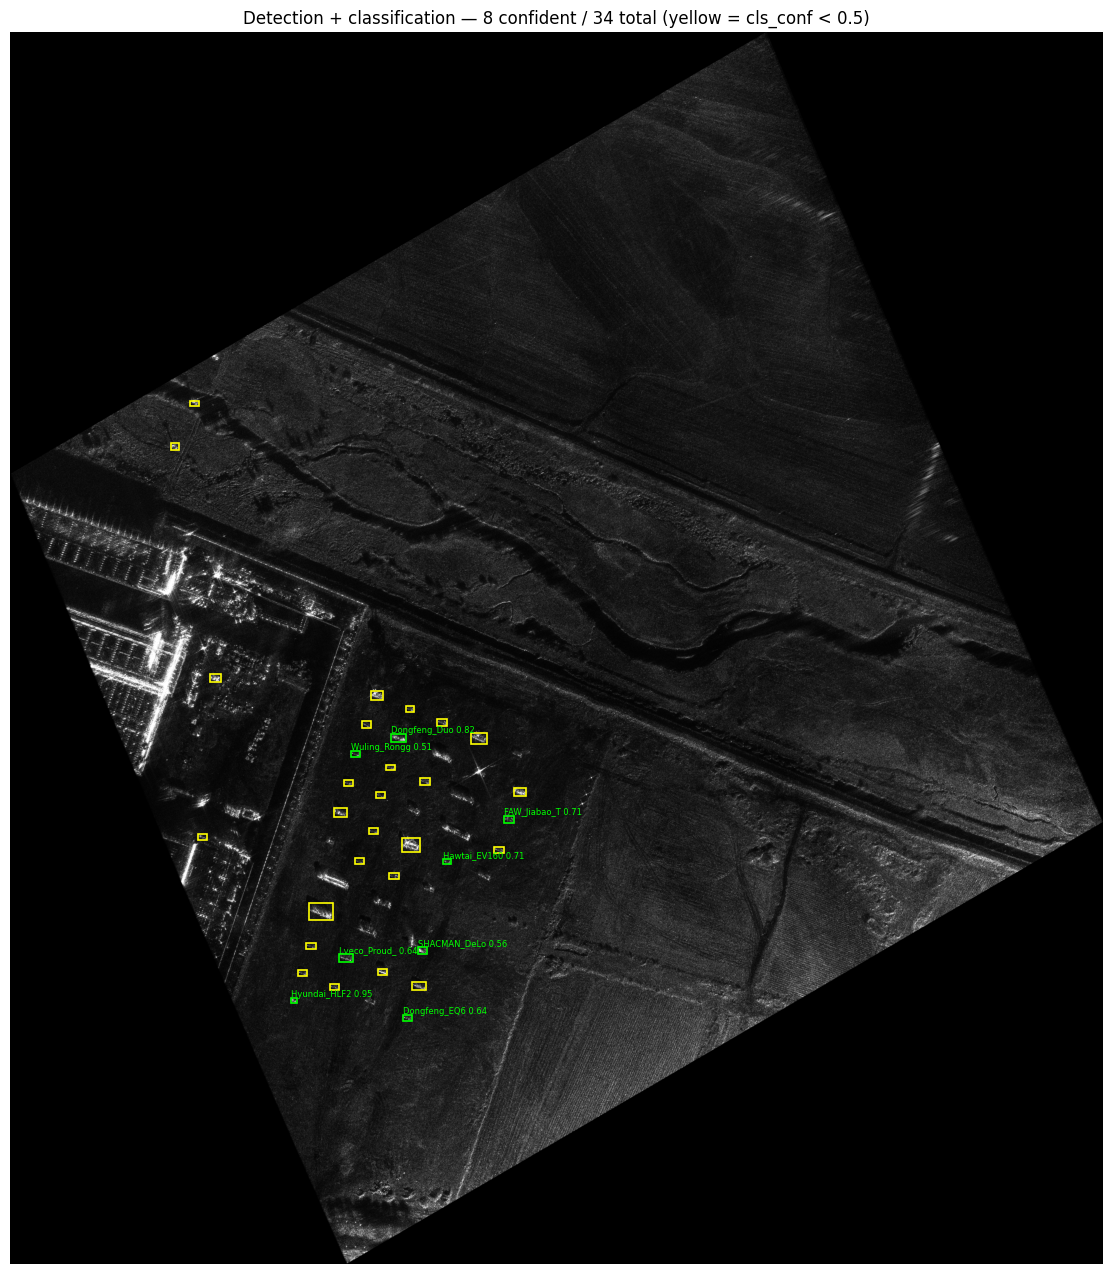

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CLS_CONF_TH = 0.5      # 분류 신뢰도 임계값 — 이보다 낮으면 "의심 박스"(노란색)

fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(scene_rgb[:, :, 0], cmap="gray")

for d in detections:
    x1, y1, x2, y2 = d["box"]
    confident = d["cls_conf"] >= CLS_CONF_TH
    color = "lime" if confident else "yellow"
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color=color, lw=1.2))
    if confident:                                  # 확신 박스에만 차종 라벨 표시 (가독성)
        ax.text(x1, y1 - 4, f'{d["type"][:12]} {d["cls_conf"]:.2f}',
                color=color, fontsize=6)

n_conf = sum(d["cls_conf"] >= CLS_CONF_TH for d in detections)
ax.set_title(f"Detection + classification — {n_conf} confident / {len(detections)} total "
             f"(yellow = cls_conf < {CLS_CONF_TH})")
ax.axis("off"); plt.show()

## 6. 장면 정량 평가 (정답 xml 대조)

장면 어노테이션(PASCAL VOC xml)의 정답 박스·차종과 대조해 3단계로 채점:

1. **탐지 recall**: 정답 표적 중 IoU≥0.3으로 매칭된 박스 비율
2. **End-to-End 정확도**: 탐지 성공 + 차종까지 정답인 비율 ← 파이프라인 최종 성적
3. **분류 정확도(탐지 성공분)**: 탐지된 표적 중 차종 정답 비율 → 실장면에서의 분류기 성능

이 셀의 수치 3개가 보고서 결과 표의 한 행이 된다 (분류기별로 반복 측정).

정답 표적: 40대
1) 탐지 recall:            28/40 = 70.0%   (ResNet18 버전: 95.0%)
2) End-to-End 정확도:      6/40 = 15.0%   (ResNet18 버전: 70.0%)
3) 분류 정확도(탐지 성공분): 6/28 = 21.4%   (ResNet18 버전: 73.7%)


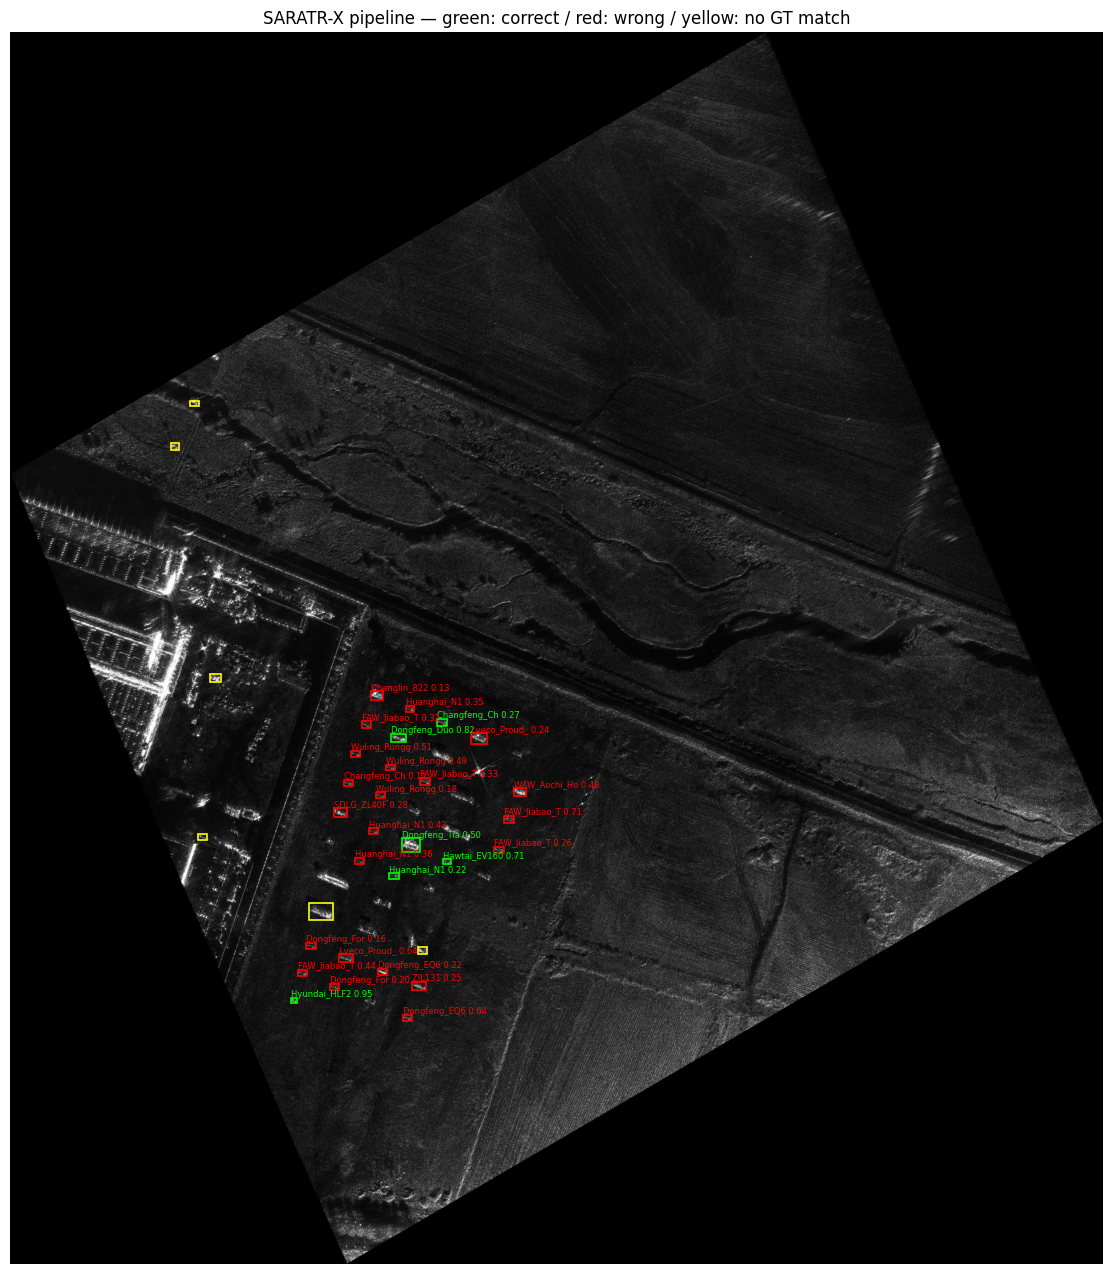

In [ ]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----- 정답 로드 -----
ann_path = SCENE.replace("/Result/", "/Annotation/").replace(".tif", ".xml")
root = ET.parse(ann_path).getroot()
gt = []
for obj in root.findall("object"):
    bb = obj.find("bndbox")
    box = [float(bb.find(t).text) for t in ["xmin", "ymin", "xmax", "ymax"]]
    gt.append((box, obj.find("type").text))

def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-9)

# ----- 3단계 채점 -----
n_det, n_cls = 0, 0
for g_box, g_type in gt:
    cands = [(iou(g_box, d["box"]), d) for d in detections if iou(g_box, d["box"]) >= 0.3]
    if not cands:
        continue
    n_det += 1
    _, best = max(cands, key=lambda c: c[0])
    if best["type"] == g_type:
        n_cls += 1

N = len(gt)
print(f"정답 표적: {N}대")
print(f"1) 탐지 recall:            {n_det}/{N} = {n_det/N*100:.1f}%   (ResNet18 버전: 95.0%)")
print(f"2) End-to-End 정확도:      {n_cls}/{N} = {n_cls/N*100:.1f}%   (ResNet18 버전: 70.0%)")
print(f"3) 분류 정확도(탐지 성공분): {n_cls}/{max(n_det,1)} = {n_cls/max(n_det,1)*100:.1f}%   (ResNet18 버전: 73.7%)")

# ----- 정답 대조 시각화 -----
fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(scene_rgb[:, :, 0], cmap="gray")
for d in detections:
    cands = [(iou(g_box, d["box"]), g_type) for g_box, g_type in gt if iou(g_box, d["box"]) >= 0.3]
    if not cands:
        color = "yellow"
    else:
        _, g_type = max(cands, key=lambda c: c[0])
        color = "lime" if d["type"] == g_type else "red"
    x1, y1, x2, y2 = d["box"]
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color=color, lw=1.2))
    if color != "yellow":
        ax.text(x1, y1 - 4, f'{d["type"][:12]} {d["cls_conf"]:.2f}', color=color, fontsize=6)
ax.set_title(f"SARATR-X pipeline — green: correct / red: wrong / yellow: no GT match")
ax.axis("off"); plt.show()

In [ ]:
from PIL import Image
import numpy as np
for idx in [0, 8]:   # ID1 HH vs ID9 HH
    img = np.array(Image.open(scene_tifs[idx]).convert("L"))
    valid = img[img > 0]   # 검은 여백 제외
    print(f"[{idx}] {scene_tifs[idx].split('/')[-2]}: 평균 {valid.mean():.1f}, 상위1% {np.percentile(valid, 99):.0f}")

[0] 30deg_0azi_ID1: 평균 28.6, 상위1% 255
[8] 30deg_150azi_ID9: 평균 32.3, 상위1% 146


## 결과 해석 가이드

| 항목 | 비교 대상 | 의미 |
|------|----------|------|
| 탐지 recall | stage1 장면 recall (95%) | 비슷해야 정상 |
| 분류 정확도(탐지 성공분) | stage2 슬라이스 단독 정확도 | 차이 = 크롭 품질/도메인 차이로 인한 손실 |
| End-to-End | ≈ recall × 분류 정확도 | 파이프라인 종합 성능 |

주의: 분류기는 X+Ku밴드 슬라이스로 학습했지만 DOM 장면은 Ku밴드 — 장면별 결과 차이가 있다면
밴드/편파(파일명에 표기)별로 나눠 분석할 것.

## 다음 단계
1. 분류기 5종에 대해 이 노트북 반복 (셀 3의 분류기 블록만 교체) → 결과 표 완성
2. 같은 방식으로 다른 장면/방위각에서도 측정하면 강인성 분석 가능
3. (선택) 논문의 SOC-50 fine-grained 탐지(YOLOv8 mAP50 64.4)와 우리 2단계 방식의 비교 논의